**Consumer Credit Prediction Model**

**Objective**

The objective of this notebook is to predict Consumer Credit using UK macroeconomic and retail banking variables. Feature engineering and normalization are performed before model training, and three regression models are compared: Linear Regression, Random Forest and XGBoost.

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

****Load the Dataset****

In [3]:
df = pd.read_csv("FINAL_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,101598,54232
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211


****Feature Engineering****

In [4]:
# Create lag features for Consumer Credit
df["ConsumerCredit_Lag1"] = df["Consumer_Credit"].shift(1)


# Remove rows with missing lag values
df_model = df.dropna().reset_index(drop=True)

# Display the first five rows
df_model.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,ConsumerCredit_Lag1
0,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375,101598.0
1,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471,102081.0
2,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404,101945.0
3,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211,101756.0
4,2008-06-01,2008,June,5.00,3.8,5.5,64.2,-0.5,33348,241184,35391,100691,54955,101556.0


**Feature Selection**

In [5]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "ConsumerCredit_Lag1"
]

# Create modelling dataframe
df_model = df[features + ["Consumer_Credit"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["Consumer_Credit"]

print(X.shape, y.shape)

(215, 5) (215,)


**Correlation Analysis**

In [6]:
# Correlation matrix
corr_matrix = df_model[features + ["Consumer_Credit"]].corr()

# Display correlation with the target variable
cc_corr = corr_matrix["Consumer_Credit"].sort_values(ascending=False)

print(cc_corr)

Consumer_Credit        1.000000
ConsumerCredit_Lag1    0.997054
Bank_Rate              0.295527
CPI                   -0.022303
Unemployment_Rate     -0.035888
GDP_Growth            -0.146548
Name: Consumer_Credit, dtype: float64


**Multicollinearity Analysis (VIF)**

In [7]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

               Feature        VIF
4  ConsumerCredit_Lag1  16.094918
3    Unemployment_Rate  12.901992
1                  CPI   2.975439
0            Bank_Rate   2.316247
2           GDP_Growth   1.016025


**Chronological train/test split**

In [8]:
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Consumer_Credit"]
y_test = test["Consumer_Credit"]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (172, 5), Test shape: (43, 5)


**Standardize the features**

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}, Scaled test shape: {X_test_scaled.shape}")

Scaled train shape: (172, 5), Scaled test shape: (43, 5)


**Linear Regression Model**

In [10]:
# Train the Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Linear Regression Evaluation**

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R² Score :", round(lr_r2, 4))
print("MAE      :", round(lr_mae, 2))
print("RMSE     :", round(lr_rmse, 2))

Linear Regression Results
R² Score : 0.8928
MAE      : 698.69
RMSE     : 921.09


**Linear Regression Coefficients**

In [12]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df)

               Feature   Coefficient
4  ConsumerCredit_Lag1  10422.410634
0            Bank_Rate    254.244058
2           GDP_Growth     84.242089
1                  CPI    -84.136495
3    Unemployment_Rate   -261.236979


**Ordinary Least Squares (OLS) Regression**

In [13]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display statistical summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Consumer_Credit   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8550.
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          3.34e-198
Time:                        01:59:13   Log-Likelihood:                -1360.6
No. Observations:                 172   AIC:                             2733.
Df Residuals:                     166   BIC:                             2752.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.401e+04     51.202   1445.540      0.0

**Actual vs Predicted Consumer Credit**

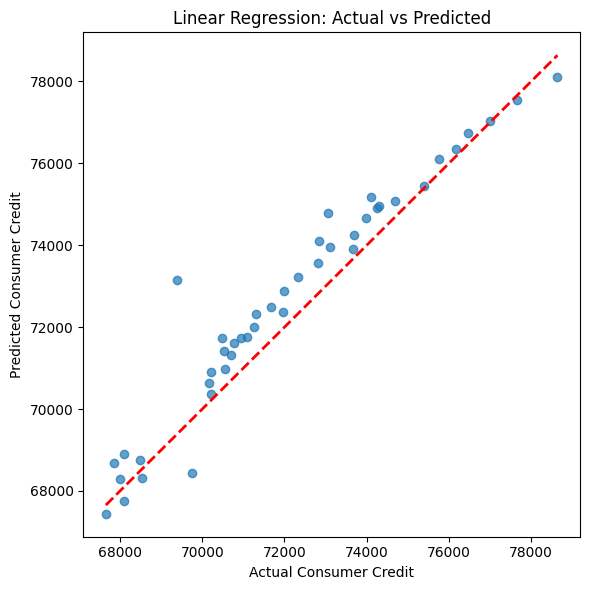

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Consumer Credit")
plt.ylabel("Predicted Consumer Credit")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

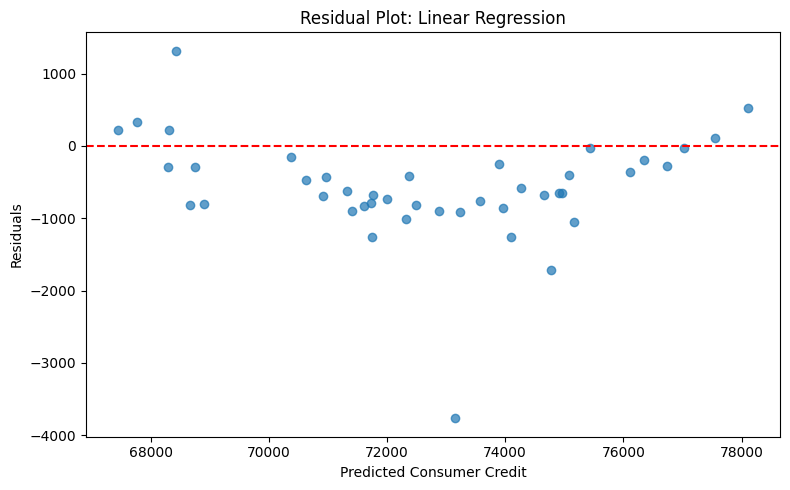

In [15]:
# Calculate residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Consumer Credit")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()

**Random Forest Regression**

In [16]:
# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Random Forest Feature Importance**

In [17]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

               Feature  Importance
4  ConsumerCredit_Lag1    0.984680
3    Unemployment_Rate    0.006421
0            Bank_Rate    0.006307
2           GDP_Growth    0.001641
1                  CPI    0.000951


**Random Forest Evaluation**

In [18]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score :", round(rf_r2, 4))
print("MAE      :", round(rf_mae, 2))
print("RMSE     :", round(rf_rmse, 2))

Random Forest Results
R² Score : 0.9215
MAE      : 584.08
RMSE     : 787.92


**Actual vs Predicted Consumer Credit**

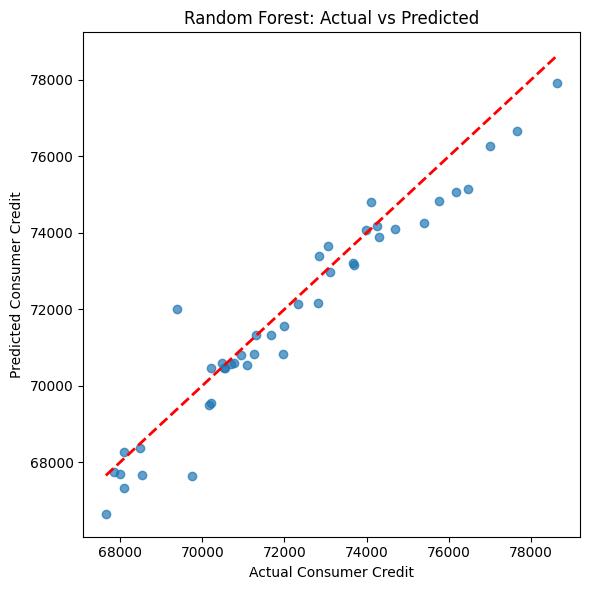

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Consumer Credit")
plt.ylabel("Predicted Consumer Credit")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

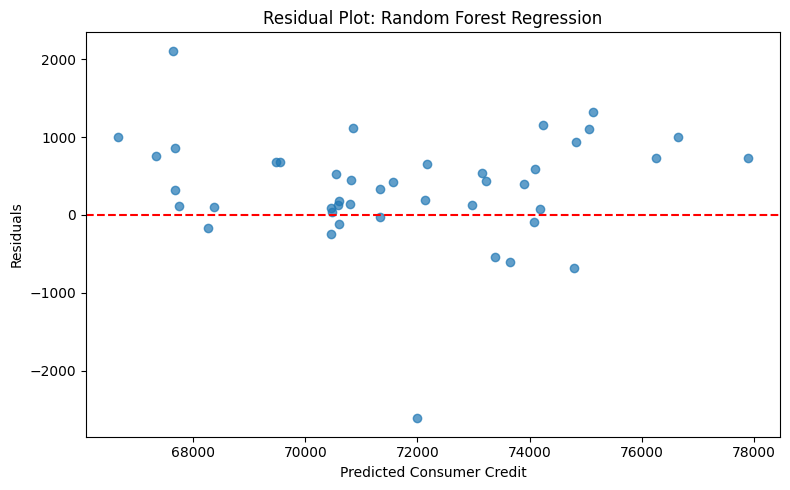

In [20]:
# Calculate residuals
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Consumer Credit")
plt.ylabel("Residuals")
plt.title("Residual Plot: Random Forest Regression")
plt.tight_layout()
plt.show()

**XGBoost Regression**

In [21]:
# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**XGBoost Feature Importance**

In [22]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False)

print(xgb_importance)

               Feature  Importance
4  ConsumerCredit_Lag1    0.605575
0            Bank_Rate    0.322586
3    Unemployment_Rate    0.035381
2           GDP_Growth    0.021519
1                  CPI    0.014939


**XGBoost Evaluation**

In [23]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("R² Score :", round(xgb_r2, 4))
print("MAE      :", round(xgb_mae, 2))
print("RMSE     :", round(xgb_rmse, 2))

XGBoost Results
R² Score : -0.6144
MAE      : 3419.51
RMSE     : 3573.96


**Actual vs Predicted Consumer Credit**

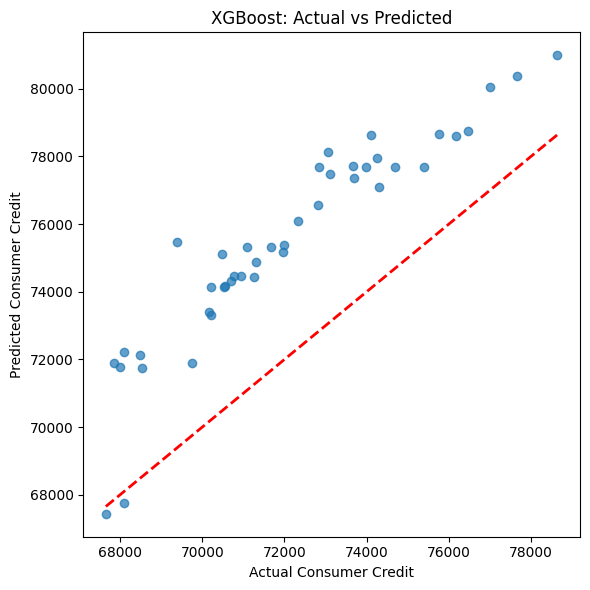

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Consumer Credit")
plt.ylabel("Predicted Consumer Credit")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

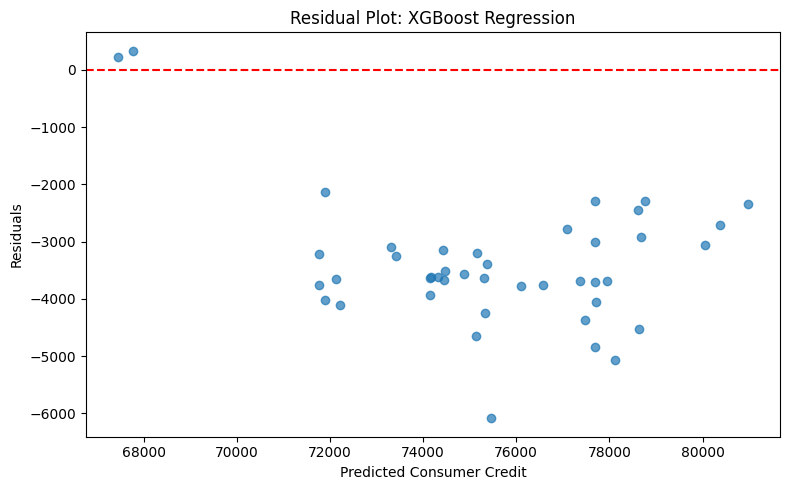

In [25]:
# Calculate residuals
xgb_residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(y_pred_xgb, xgb_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Consumer Credit")
plt.ylabel("Residuals")
plt.title("Residual Plot: XGBoost Regression")
plt.tight_layout()
plt.show()

**Model Comparison**

In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [lr_r2, rf_r2, xgb_r2],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

comparison = comparison.sort_values(by="R²", ascending=False)

print(comparison)

               Model        R²          MAE         RMSE
1      Random Forest  0.921532   584.080762   787.923238
0  Linear Regression  0.892767   698.686793   921.089757
2            XGBoost -0.614443  3419.510254  3573.958729


**Model Comparison Visualization**

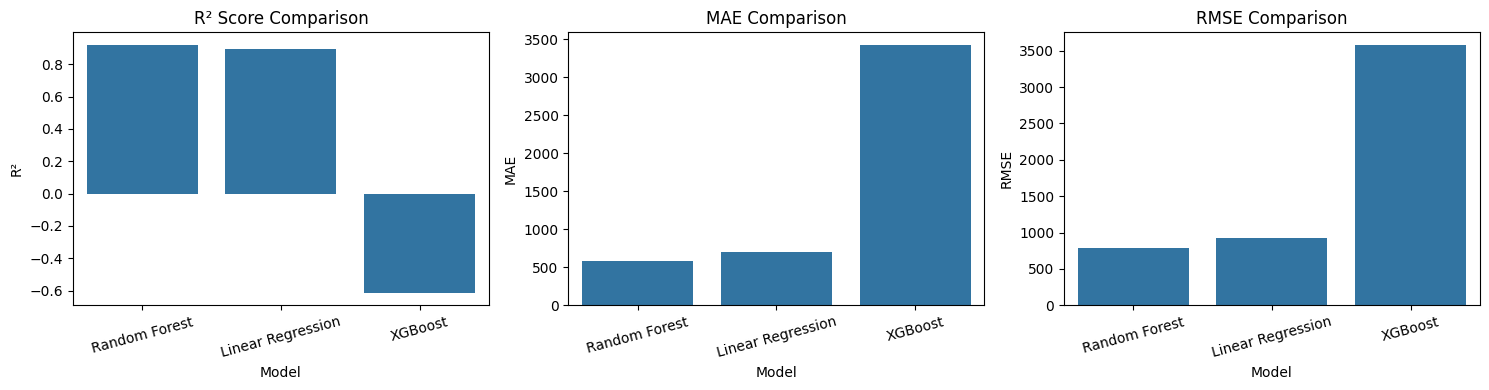

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# R²
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    ax=axes[0]
)
axes[0].set_title("R² Score Comparison")
axes[0].tick_params(axis="x", rotation=15)

# MAE
sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    ax=axes[1]
)
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

# RMSE
sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[2]
)
axes[2].set_title("RMSE Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [28]:
import joblib
import os

os.makedirs("../synthetic_bank/models", exist_ok=True)

In [29]:
joblib.dump(
    rf_model,
    "../synthetic_bank/models/consumer_credit_rf.pkl"
)

['../synthetic_bank/models/consumer_credit_rf.pkl']

In [30]:
consumer_credit_features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "ConsumerCredit_Lag1"
]

joblib.dump(
    consumer_credit_features,
    "../synthetic_bank/models/consumer_credit_features.pkl"
)

['../synthetic_bank/models/consumer_credit_features.pkl']

In [31]:
latest_consumer_credit = df["Consumer_Credit"].iloc[-1]

joblib.dump(
    latest_consumer_credit,
    "../synthetic_bank/models/consumer_credit_latest.pkl"
)

['../synthetic_bank/models/consumer_credit_latest.pkl']